# BQR-DN V2 training on VOC2007

Trains the `bqr_dn_v2` method: official DINO R50 with region-aware pre-conditioning of training-only denoising queries. Normal detection and inference paths remain official DINO.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
from gt_guided_dino.api import ExperimentConfig, train
print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

d:\BQR_DETR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.1+cu126 cuda: True
NVIDIA GeForce RTX 3060


In [2]:
config = ExperimentConfig(
    data_root=PROJECT_ROOT / 'VOC2007',
    output_root=PROJECT_ROOT / 'artifacts',
    method='bqr_dn_v2',
    epochs=12,
    train_limit=1000,
    lr_drop_epoch=11,
    bqr_enabled=True,
    bqr_dn_weight=1.0,
    bqr_points_per_level=4,
    bqr_gate_bias=-2.0,
)
config

ExperimentConfig(data_root=WindowsPath('D:/BQR_DETR/VOC2007'), output_root=WindowsPath('D:/BQR_DETR/artifacts'), torch_cache=WindowsPath('D:/BQR_DETR/weights/torch'), method='bqr_dn_v2', seed=42, train_limit=1000, val_limit=None, epochs=12, batch_size=1, accumulation_steps=4, num_workers=0, precision='fp16', lr=0.0001, backbone_lr=1e-05, weight_decay=0.0001, grad_clip=0.1, lr_drop_epoch=11, lr_drop_gamma=0.1, save_every=1, num_queries=900, hidden_dim=256, enc_layers=6, dec_layers=6, dim_feedforward=2048, num_feature_levels=4, dn_number=100, train_scales=(480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800), train_max_size=1333, crop_resize_scales=(400, 500, 600), crop_min_size=384, crop_max_size=600, use_random_crop=True, val_size=800, val_max_size=1333, aux_weight=1.0, aux_l1_coef=5.0, aux_giou_coef=2.0, sampling_points_per_level=4, bqr_enabled=True, bqr_dn_weight=1.0, bqr_points_per_level=4, bqr_gate_bias=-2.0)

In [3]:
# Resumes artifacts/bqr_dn_v2/seed_42/checkpoints/latest.pt when present.
history = train(config, resume=True)
history[-1]

epoch=01 loss=40.2566 lr=1.00e-04 seconds=463.1


epoch=02 loss=27.3667 lr=1.00e-04 seconds=437.1


epoch=03 loss=22.3910 lr=1.00e-04 seconds=420.5


epoch=04 loss=19.8091 lr=1.00e-04 seconds=427.7


epoch=05 loss=18.1572 lr=1.00e-04 seconds=427.2


...

epoch=09 loss=14.3463 lr=1.00e-04 seconds=474.4


epoch=10 loss=13.4853 lr=1.00e-04 seconds=481.1


epoch=11 loss=13.1806 lr=1.00e-04 seconds=478.4


epoch=12 loss=11.7440 lr=1.00e-05 seconds=478.0


{'epoch': 12,
 'lr': 1e-05,
 'loss': 11.744049177378416,
 'batches': 1000,
 'optimizer_steps': 250,
 'seconds': 478.0406740000035,
 'peak_cuda_mb': 11342.82373046875,
 'loss_ce': 0.2966533634462394,
 'loss_bbox': 0.06195901265647262,
 'loss_giou': 0.13751421477645637,
 'loss_ce_dn': 0.05650533399672713,
 'loss_bbox_dn': 0.07309838703554124,
 'loss_giou_dn': 0.1389664057120681,
 'bqr_valid_queries': 198.458,
 'bqr_gate_mean': 0.8508625248372554,
 'bqr_offset_abs_mean': 0.16473794554173946,
 'bqr_attention_entropy': 2.470904346704483,
 'bqr_region_norm': 13.26152520275116,
 'bqr_fusion_delta_norm': 9.25032225728035}

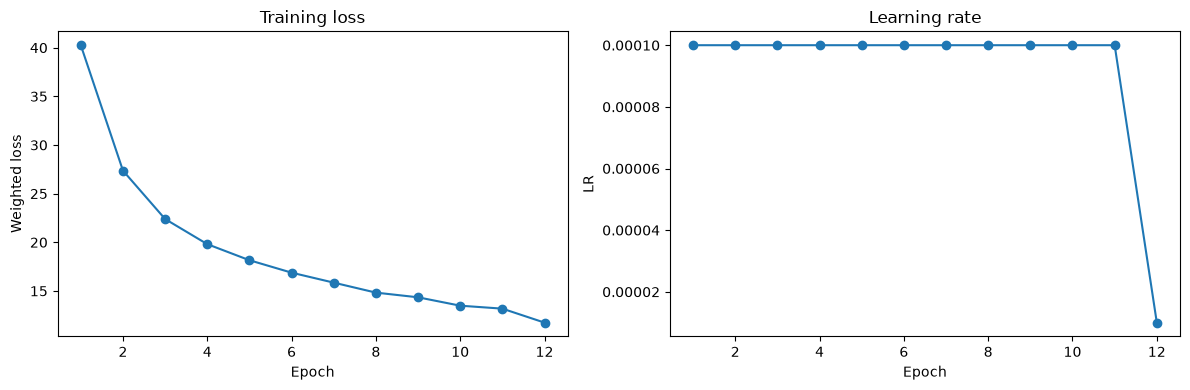

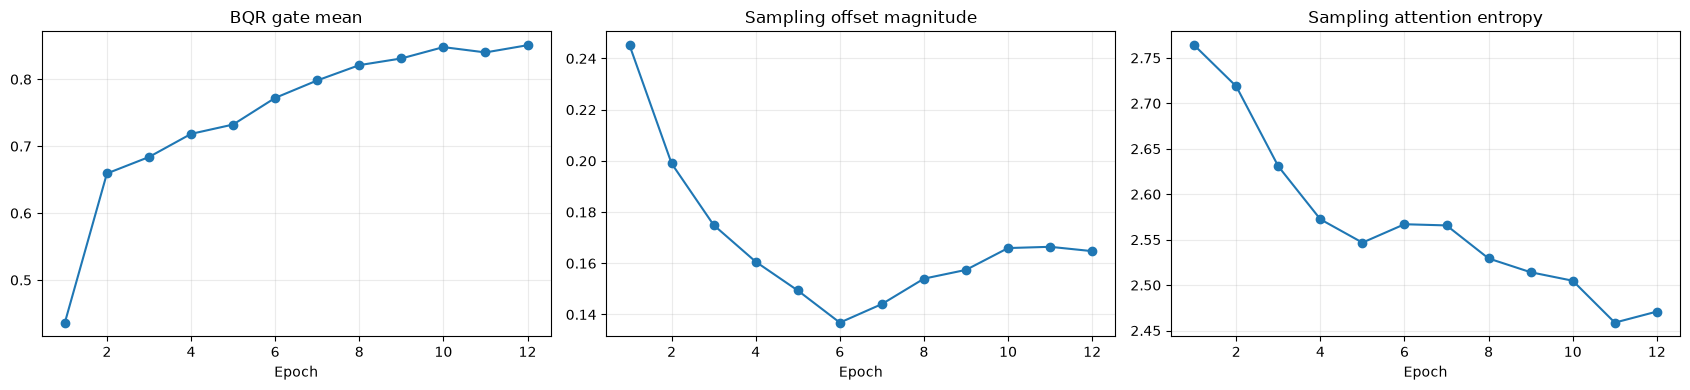

In [4]:
import matplotlib.pyplot as plt
from gt_guided_dino.visualization import plot_history

plot_history(config.history_path);

epochs = [row['epoch'] for row in history]
figure, axes = plt.subplots(1, 3, figsize=(17, 4))
for axis, key, title in (
    (axes[0], 'bqr_gate_mean', 'BQR gate mean'),
    (axes[1], 'bqr_offset_abs_mean', 'Sampling offset magnitude'),
    (axes[2], 'bqr_attention_entropy', 'Sampling attention entropy'),
):
    axis.plot(epochs, [row.get(key, float('nan')) for row in history], marker='o')
    axis.set(title=title, xlabel='Epoch')
    axis.grid(alpha=0.25)
figure.tight_layout()